In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os
import cv2
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm

In [3]:
NIH_PATH = "/kaggle/input/chest-xray14/images"
IU_IMG_PATH = "/kaggle/input/openi/images"
IU_REPORT_PATH = "/kaggle/input/openi/reports"
COVID_PATH = "/kaggle/input/covidx-cxr2"

In [50]:
for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    print(files[:5])
    print("-"*50)

/kaggle/input
[]
--------------------------------------------------
/kaggle/input/datasets
[]
--------------------------------------------------
/kaggle/input/datasets/andyczhao
[]
--------------------------------------------------
/kaggle/input/datasets/andyczhao/covidx-cxr2
['val.txt', 'test.txt', 'train.txt']
--------------------------------------------------
/kaggle/input/datasets/andyczhao/covidx-cxr2/val
['COVID(47).png', 'sub-S09736_ses-E25124_run-1_bp-chest_vp-pa_dx-corrected.png', 'sub-S10114_ses-E19830_run-1_bp-chest_vp-ap_cr-corrected.png', '39ebb0a8-3fad-42c6-83d1-b92272c32f6f.png', 'sub-S09678_ses-E22133_run-1_bp-chest_vp-ap_dx-corrected.png']
--------------------------------------------------
/kaggle/input/datasets/andyczhao/covidx-cxr2/test
['sub-S05073_ses-E12362_run-1_bp-chest_vp-pa_dx-corrected.png', 'sub-S06722_ses-E13548_run-1_bp-chest_vp-pa_cr-corrected.png', 'sub-S05456_ses-E10137_run-1_bp-chest_vp-ap_cr-corrected.png', 'sub-S03263_ses-E06433_run-1_bp-chest_vp-ap_

In [ ]:
# NIH metadata creation

In [5]:
import pandas as pd

nih_df = pd.read_csv(
    "/kaggle/input/datasets/biditdas06/nih-chestxray14/Data_Entry_2017_v2020.csv"
)

nih_df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
0,00000001_000.png,Cardiomegaly,0,1,57,M,PA,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168
3,00000002_000.png,No Finding,0,2,80,M,PA,2500,2048,0.171,0.171
4,00000003_001.png,Hernia,0,3,74,F,PA,2500,2048,0.168,0.168


In [ ]:
nih_df.info()

In [ ]:
nih_df.columns

In [6]:
nih_metadata = nih_df[["Image Index", "Finding Labels"]]
nih_metadata = nih_metadata.rename(columns={
    "Image Index": "image_name",
    "Finding Labels": "disease_labels"
})

nih_metadata.head()

,image_name,disease_labels
0,00000001_000.png,Cardiomegaly
1,00000001_001.png,Cardiomegaly|Emphysema
2,00000001_002.png,Cardiomegaly|Effusion
3,00000002_000.png,No Finding
4,00000003_001.png,Hernia


In [7]:
import os

nih_root = "/kaggle/input/datasets/biditdas06/nih-chestxray14"

image_paths = {}

for root, dirs, files in os.walk(nih_root):
    for file in files:
        if file.endswith(".png"):
            image_paths[file] = os.path.join(root, file)

nih_metadata["image_path"] = nih_metadata["image_name"].map(image_paths)

nih_metadata.head()

,image_name,disease_labels,image_path
0,00000001_000.png,Cardiomegaly,/kaggle/input/datasets/biditdas06/nih-chestxra...
1,00000001_001.png,Cardiomegaly|Emphysema,/kaggle/input/datasets/biditdas06/nih-chestxra...
2,00000001_002.png,Cardiomegaly|Effusion,/kaggle/input/datasets/biditdas06/nih-chestxra...
3,00000002_000.png,No Finding,/kaggle/input/datasets/biditdas06/nih-chestxra...
4,00000003_001.png,Hernia,/kaggle/input/datasets/biditdas06/nih-chestxra...


In [8]:
print("Missing image paths:", nih_metadata["image_path"].isnull().sum())

Missing image paths: 0


In [9]:
nih_metadata.to_csv("nih_metadata.csv", index=False)

print("NIH metadata saved successfully!")

NIH metadata saved successfully!


# IUXRay metadata creation

In [10]:
import os
import xml.etree.ElementTree as ET
import pandas as pd

In [11]:
REPORT_PATH = "/kaggle/input/datasets/biditdas06/iu-x-ray/nlm_cxr_reports/ecgen-radiology"
IMAGE_PATH = "/kaggle/input/datasets/biditdas06/iu-x-ray/nlm_cxr_png"

In [12]:
report_files = [f for f in os.listdir(REPORT_PATH) if f.endswith(".xml")]

print("Total XML Reports:", len(report_files))

Total XML Reports: 3955


In [13]:
sample = report_files[0]

tree = ET.parse(os.path.join(REPORT_PATH, sample))
root = tree.getroot()

print(ET.tostring(root, encoding="unicode")[:2000])

<eCitation>
   <meta type="rr" />
   <uId id="CXR3468" />
   <pmcId id="3468" />
   <docSource>CXR</docSource>
   <IUXRId id="3468" />
   <licenseType>open-access</licenseType>
   <licenseURL>http://creativecommons.org/licenses/by-nc-nd/4.0/</licenseURL>
   <ccLicense>byncnd</ccLicense>
   <articleURL />
   <articleDate>2013-08-01</articleDate>
   <articleType>XR</articleType>
   <publisher>Indiana University</publisher>
   <title>Indiana University Chest X-ray Collection</title>
   <note>The data are drawn from multiple hospital systems.</note>
   <specialty>pulmonary diseases</specialty>
   <subset>CXR</subset>
   <MedlineCitation Owner="Indiana University" Status="supplied by publisher">
   
      <Article PubModel="Electronic">
      
         <Journal>
         
            <JournalIssue>
            
               <PubDate>
               
                  <Year>2013</Year>
               
                  <Month>08</Month>
               
                  <Day>01</Day>
     

In [14]:
for elem in root.iter():
    print(elem.tag, elem.attrib)

eCitation {}
meta {'type': 'rr'}
uId {'id': 'CXR3468'}
pmcId {'id': '3468'}
docSource {}
IUXRId {'id': '3468'}
licenseType {}
licenseURL {}
ccLicense {}
articleURL {}
articleDate {}
articleType {}
publisher {}
title {}
note {}
specialty {}
subset {}
MedlineCitation {'Owner': 'Indiana University', 'Status': 'supplied by publisher'}
Article {'PubModel': 'Electronic'}
Journal {}
JournalIssue {}
PubDate {}
Year {}
Month {}
Day {}
ArticleTitle {}
Abstract {}
AbstractText {'Label': 'COMPARISON'}
AbstractText {'Label': 'INDICATION'}
AbstractText {'Label': 'FINDINGS'}
AbstractText {'Label': 'IMPRESSION'}
Affiliation {}
AuthorList {'CompleteYN': 'Y'}
Author {'ValidYN': 'Y'}
LastName {}
ForeName {}
Initials {}
Author {'ValidYN': 'Y'}
LastName {}
ForeName {}
Initials {}
Language {}
PublicationTypeList {}
PublicationType {}
ArticleDate {}
Year {}
Month {}
Day {}
EssieArticleTitle {}
IMedAuthor {}
IMedAuthor {}
MeSH {}
major {}
major {}
major {}
major {}
major {}
automatic {}
automatic {}
automatic

In [15]:
records = []

for xml_file in report_files:

    tree = ET.parse(os.path.join(REPORT_PATH, xml_file))
    root = tree.getroot()

    findings = ""
    impression = ""

    # Extract Findings and Impression
    for elem in root.iter("AbstractText"):
        label = elem.attrib.get("Label", "")

        if label == "FINDINGS":
            findings = elem.text if elem.text else ""

        elif label == "IMPRESSION":
            impression = elem.text if elem.text else ""

    # Extract all linked images
    for img in root.iter("parentImage"):

        image_name = img.attrib["id"] + ".png"
        image_path = os.path.join(IMAGE_PATH, image_name)

        records.append({
            "report_id": xml_file.replace(".xml", ""),
            "image_name": image_name,
            "image_path": image_path,
            "findings": findings,
            "impression": impression
        })

iuxray_metadata = pd.DataFrame(records)

iuxray_metadata.head()

,report_id,image_name,image_path,findings,impression
0,3468,CXR3468_IM-1684-0001-0001.png,/kaggle/input/datasets/biditdas06/iu-x-ray/nlm...,Heart size is at the upper limits of normal. T...,1. No focal airspace consolidation. 2. Emphyse...
1,3468,CXR3468_IM-1684-0001-0002.png,/kaggle/input/datasets/biditdas06/iu-x-ray/nlm...,Heart size is at the upper limits of normal. T...,1. No focal airspace consolidation. 2. Emphyse...
2,3468,CXR3468_IM-1684-0001-0003.png,/kaggle/input/datasets/biditdas06/iu-x-ray/nlm...,Heart size is at the upper limits of normal. T...,1. No focal airspace consolidation. 2. Emphyse...
3,3468,CXR3468_IM-1684-0001-0004.png,/kaggle/input/datasets/biditdas06/iu-x-ray/nlm...,Heart size is at the upper limits of normal. T...,1. No focal airspace consolidation. 2. Emphyse...
4,1853,CXR1853_IM-0555-1001.png,/kaggle/input/datasets/biditdas06/iu-x-ray/nlm...,"The lungs are clear bilaterally. Specifically,...",No acute cardiopulmonary abnormality.


In [16]:
print(iuxray_metadata.shape)
iuxray_metadata.head()
iuxray_metadata.sample(5)
iuxray_metadata.info()
print(iuxray_metadata.isnull().sum())

(7470, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7470 entries, 0 to 7469
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   report_id   7470 non-null   object
 1   image_name  7470 non-null   object
 2   image_path  7470 non-null   object
 3   findings    7470 non-null   object
 4   impression  7470 non-null   object
dtypes: object(5)
memory usage: 291.9+ KB
report_id     0
image_name    0
image_path    0
findings      0
impression    0
dtype: int64


In [17]:
iuxray_metadata = iuxray_metadata[
    [
        "image_name",
        "image_path",
        "report_id",
        "findings",
        "impression"
    ]
]

In [18]:
iuxray_metadata.sample(5)

,image_name,image_path,report_id,findings,impression
389,CXR2633_IM-1120-3003.png,/kaggle/input/datasets/biditdas06/iu-x-ray/nlm...,2633,Heart size is normal. Prior calcified granulom...,2.1 cm nodular density in the anterior costoph...
3313,CXR1721_IM-0476-1001.png,/kaggle/input/datasets/biditdas06/iu-x-ray/nlm...,1721,"The heart, pulmonary XXXX and mediastinum are ...",No acute cardiopulmonary disease.
3007,CXR3753_IM-1877-2001.png,/kaggle/input/datasets/biditdas06/iu-x-ray/nlm...,3753,"The cardiac silhouette, upper mediastinum and ...",1. No focal pulmonary consolidation or effusio...
3418,CXR2595_IM-1086-1001.png,/kaggle/input/datasets/biditdas06/iu-x-ray/nlm...,2595,"The lungs are clear bilaterally. Specifically,...",No acute cardiopulmonary abnormality..
7038,CXR3311_IM-1586-1001.png,/kaggle/input/datasets/biditdas06/iu-x-ray/nlm...,3311,The lungs are clear. There is no pleural effus...,No active disease.


In [19]:
iuxray_metadata.to_csv("iuxray_metadata.csv", index=False)

print("IU-Xray metadata saved successfully!")

IU-Xray metadata saved successfully!


# COVIDx metadata creation

In [ ]:
#covidx metadata

In [20]:
COVID_PATH = "/kaggle/input/datasets/andyczhao/covidx-cxr2"

train_file = os.path.join(COVID_PATH, "train.txt")
test_file = os.path.join(COVID_PATH, "test.txt")
val_file = os.path.join(COVID_PATH, "val.txt")

In [21]:
with open(train_file, "r") as f:
    for _ in range(5):
        print(f.readline())

379 1e64990d1b40c1758a2aaa9c7f7a85_jumbo.jpeg negative cohen

379 7223b8ad031187d9a142d7f7ca02c9_jumbo.jpeg negative cohen

380 3392dc7d262e28423caca517f98c2e_jumbo.jpeg negative cohen

380 ec3a480c0926ded74429df416cfb05_jumbo.jpeg negative cohen

382 a72aeb349a63c79ed24e473c434efe_jumbo.jpg negative cohen



In [22]:
with open(val_file, "r") as f:
    for _ in range(5):
        print(f.readline())

ANON196 CR.1.2.840.113564.1722810170.20200318082923328940.1003000225002.png positive actmed

ANON170 CR.1.2.840.113564.1722810170.20200320011259312440.1003000225002.png positive actmed

S03044 sub-S03044_ses-E06138_run-1_bp-chest_vp-ap_cr-corrected.png positive bimcv

S03044 sub-S03044_ses-E07712_run-1_bp-chest_vp-ap_cr-corrected.png positive bimcv

S03044 sub-S03044_ses-E06790_run-1_bp-chest_vp-pa_dx-corrected.png positive bimcv



In [23]:
with open(test_file, "r") as f:
    for _ in range(5):
        print(f.readline())

419639-003251 MIDRC-RICORD-1C-419639-003251-46647-0.png positive ricord

419639-001464 MIDRC-RICORD-1C-419639-001464-39871-0.png positive ricord

419639-000918 MIDRC-RICORD-1C-419639-000918-78965-0.png positive ricord

419639-003318 MIDRC-RICORD-1C-419639-003318-64285-0.png positive ricord

419639-001015 MIDRC-RICORD-1C-419639-001015-81591-0.png positive ricord



In [26]:
import pandas as pd
import os
def load_split(txt_file, split_name):
    
    records = []

    with open(txt_file, "r") as f:

        for line in f:

            patient_id, image_name, label, source = line.strip().split()

            image_path = os.path.join(
                COVID_PATH,
                split_name,
                image_name
            )

            records.append({
                "patient_id": patient_id,
                "image_name": image_name,
                "image_path": image_path,
                "label": label,
                "source": source,
                "split": split_name
            })

    return pd.DataFrame(records)

In [27]:
train_df = load_split(train_file, "train")

val_df = load_split(val_file, "val")

test_df = load_split(test_file, "test")

In [28]:
covidx_metadata = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

covidx_metadata.head()

,patient_id,image_name,image_path,label,source,split
0,379,1e64990d1b40c1758a2aaa9c7f7a85_jumbo.jpeg,/kaggle/input/datasets/andyczhao/covidx-cxr2/t...,negative,cohen,train
1,379,7223b8ad031187d9a142d7f7ca02c9_jumbo.jpeg,/kaggle/input/datasets/andyczhao/covidx-cxr2/t...,negative,cohen,train
2,380,3392dc7d262e28423caca517f98c2e_jumbo.jpeg,/kaggle/input/datasets/andyczhao/covidx-cxr2/t...,negative,cohen,train
3,380,ec3a480c0926ded74429df416cfb05_jumbo.jpeg,/kaggle/input/datasets/andyczhao/covidx-cxr2/t...,negative,cohen,train
4,382,a72aeb349a63c79ed24e473c434efe_jumbo.jpg,/kaggle/input/datasets/andyczhao/covidx-cxr2/t...,negative,cohen,train


In [29]:
print(covidx_metadata.shape)

covidx_metadata.info()

print(covidx_metadata.isnull().sum())

covidx_metadata.sample(5)

(84818, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84818 entries, 0 to 84817
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   patient_id  84818 non-null  object
 1   image_name  84818 non-null  object
 2   image_path  84818 non-null  object
 3   label       84818 non-null  object
 4   source      84818 non-null  object
 5   split       84818 non-null  object
dtypes: object(6)
memory usage: 3.9+ MB
patient_id    0
image_name    0
image_path    0
label         0
source        0
split         0
dtype: int64


,patient_id,image_name,image_path,label,source,split
46522,S316686,sub-S316686_ses-E34892_run-1_bp-chest_vp-ap_dx...,/kaggle/input/datasets/andyczhao/covidx-cxr2/t...,positive,bimcv,train
66988,S334049,sub-S334049_ses-E71584_run-1_bp-chest_vp-pa_cr...,/kaggle/input/datasets/andyczhao/covidx-cxr2/t...,positive,bimcv,train
81719,S05322,sub-S05322_ses-E10329_run-1_bp-chest_vp-pa_cr-...,/kaggle/input/datasets/andyczhao/covidx-cxr2/t...,negative,bimcv,test
62623,S329000,sub-S329000_ses-E68791_run-1_bp-chest_vp-pa_cr...,/kaggle/input/datasets/andyczhao/covidx-cxr2/t...,positive,bimcv,train
63127,S329506,sub-S329506_ses-E68800_run-1_bp-chest_vp-pa_cr...,/kaggle/input/datasets/andyczhao/covidx-cxr2/t...,positive,bimcv,train


In [30]:
covidx_metadata.to_csv(
    "covidx_metadata.csv",
    index=False
)

print("COVIDx metadata saved successfully!")

COVIDx metadata saved successfully!


# metadata cleaning

In [31]:
nih_metadata = pd.read_csv("nih_metadata.csv")
iuxray_metadata = pd.read_csv("iuxray_metadata.csv")
covidx_metadata = pd.read_csv("covidx_metadata.csv")

In [32]:
print("NIH Shape:", nih_metadata.shape)
print("IU-XRay Shape:", iuxray_metadata.shape)
print("COVIDx Shape:", covidx_metadata.shape)

NIH Shape: (112120, 3)
IU-XRay Shape: (7470, 5)
COVIDx Shape: (84818, 6)


In [33]:
print("NIH")
print(nih_metadata.isnull().sum())

print("\nIU-XRay")
print(iuxray_metadata.isnull().sum())

print("\nCOVIDx")
print(covidx_metadata.isnull().sum())

NIH
image_name        0
disease_labels    0
image_path        0
dtype: int64

IU-XRay
image_name      0
image_path      0
report_id       0
findings      997
impression     52
dtype: int64

COVIDx
patient_id    0
image_name    0
image_path    0
label         0
source        0
split         0
dtype: int64


In [34]:
nih_metadata.drop_duplicates(inplace=True)

iuxray_metadata.drop_duplicates(inplace=True)

covidx_metadata.drop_duplicates(inplace=True)

In [35]:
print("NIH:", nih_metadata.duplicated().sum())

print("IU-XRay:", iuxray_metadata.duplicated().sum())

print("COVIDx:", covidx_metadata.duplicated().sum())

NIH: 0
IU-XRay: 0
COVIDx: 0


In [36]:
print(
    "Missing NIH Images:",
    (~nih_metadata["image_path"].apply(os.path.exists)).sum()
)

Missing NIH Images: 0


In [37]:
print(
    "Missing IU Images:",
    (~iuxray_metadata["image_path"].apply(os.path.exists)).sum()
)

Missing IU Images: 0


In [38]:
print(
    "Missing COVIDx Images:",
    (~covidx_metadata["image_path"].apply(os.path.exists)).sum()
)

Missing COVIDx Images: 0


# Metadata Standardization

In [39]:
nih_metadata = nih_metadata.rename(columns={
    "disease_labels": "label"
})

nih_metadata["dataset"] = "NIH"

nih_metadata.head()

,image_name,label,image_path,dataset
0,00000001_000.png,Cardiomegaly,/kaggle/input/datasets/biditdas06/nih-chestxra...,NIH
1,00000001_001.png,Cardiomegaly|Emphysema,/kaggle/input/datasets/biditdas06/nih-chestxra...,NIH
2,00000001_002.png,Cardiomegaly|Effusion,/kaggle/input/datasets/biditdas06/nih-chestxra...,NIH
3,00000002_000.png,No Finding,/kaggle/input/datasets/biditdas06/nih-chestxra...,NIH
4,00000003_001.png,Hernia,/kaggle/input/datasets/biditdas06/nih-chestxra...,NIH


In [40]:
iuxray_metadata["dataset"] = "IU-XRay"

iuxray_metadata.head()

,image_name,image_path,report_id,findings,impression,dataset
0,CXR3468_IM-1684-0001-0001.png,/kaggle/input/datasets/biditdas06/iu-x-ray/nlm...,3468,Heart size is at the upper limits of normal. T...,1. No focal airspace consolidation. 2. Emphyse...,IU-XRay
1,CXR3468_IM-1684-0001-0002.png,/kaggle/input/datasets/biditdas06/iu-x-ray/nlm...,3468,Heart size is at the upper limits of normal. T...,1. No focal airspace consolidation. 2. Emphyse...,IU-XRay
2,CXR3468_IM-1684-0001-0003.png,/kaggle/input/datasets/biditdas06/iu-x-ray/nlm...,3468,Heart size is at the upper limits of normal. T...,1. No focal airspace consolidation. 2. Emphyse...,IU-XRay
3,CXR3468_IM-1684-0001-0004.png,/kaggle/input/datasets/biditdas06/iu-x-ray/nlm...,3468,Heart size is at the upper limits of normal. T...,1. No focal airspace consolidation. 2. Emphyse...,IU-XRay
4,CXR1853_IM-0555-1001.png,/kaggle/input/datasets/biditdas06/iu-x-ray/nlm...,1853,"The lungs are clear bilaterally. Specifically,...",No acute cardiopulmonary abnormality.,IU-XRay


In [41]:
covidx_metadata["dataset"] = "COVIDx"

covidx_metadata.head()

,patient_id,image_name,image_path,label,source,split,dataset
0,379,1e64990d1b40c1758a2aaa9c7f7a85_jumbo.jpeg,/kaggle/input/datasets/andyczhao/covidx-cxr2/t...,negative,cohen,train,COVIDx
1,379,7223b8ad031187d9a142d7f7ca02c9_jumbo.jpeg,/kaggle/input/datasets/andyczhao/covidx-cxr2/t...,negative,cohen,train,COVIDx
2,380,3392dc7d262e28423caca517f98c2e_jumbo.jpeg,/kaggle/input/datasets/andyczhao/covidx-cxr2/t...,negative,cohen,train,COVIDx
3,380,ec3a480c0926ded74429df416cfb05_jumbo.jpeg,/kaggle/input/datasets/andyczhao/covidx-cxr2/t...,negative,cohen,train,COVIDx
4,382,a72aeb349a63c79ed24e473c434efe_jumbo.jpg,/kaggle/input/datasets/andyczhao/covidx-cxr2/t...,negative,cohen,train,COVIDx


In [42]:
print("NIH Columns:")
print(nih_metadata.columns)

print("\nIU-XRay Columns:")
print(iuxray_metadata.columns)

print("\nCOVIDx Columns:")
print(covidx_metadata.columns)

NIH Columns:
Index(['image_name', 'label', 'image_path', 'dataset'], dtype='object')

IU-XRay Columns:
Index(['image_name', 'image_path', 'report_id', 'findings', 'impression',
       'dataset'],
      dtype='object')

COVIDx Columns:
Index(['patient_id', 'image_name', 'image_path', 'label', 'source', 'split',
       'dataset'],
      dtype='object')


In [43]:
nih_metadata.to_csv(
    "nih_metadata_standardized.csv",
    index=False
)

iuxray_metadata.to_csv(
    "iuxray_metadata_standardized.csv",
    index=False
)

covidx_metadata.to_csv(
    "covidx_metadata_standardized.csv",
    index=False
)

print("All standardized metadata saved successfully!")

All standardized metadata saved successfully!


# Image Preprocessing

In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [52]:
def preprocess_image(image_path, img_size=(224, 224)):

    # read image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # resize
    image = cv2.resize(image, img_size)

    # clahe
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    image = clahe.apply(image)

    # normalize
    image = image.astype(np.float32) / 255.0

    return image

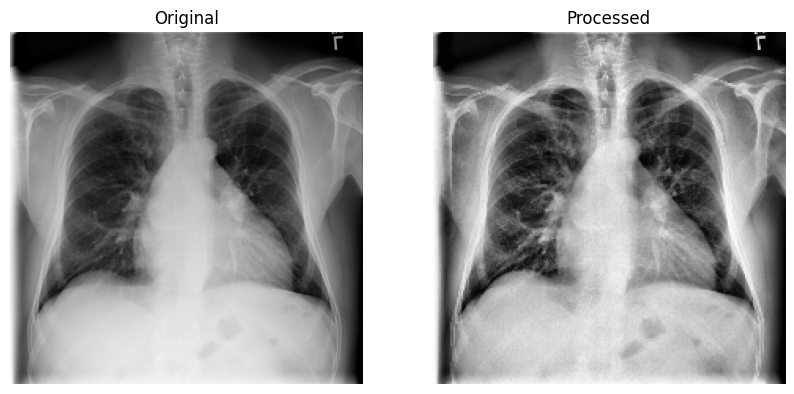

In [56]:
sample_path = nih_metadata.loc[0, "image_path"]
original = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)

processed = preprocess_image(sample_path)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(processed, cmap="gray")
plt.title("Processed")
plt.axis("off")

plt.show()

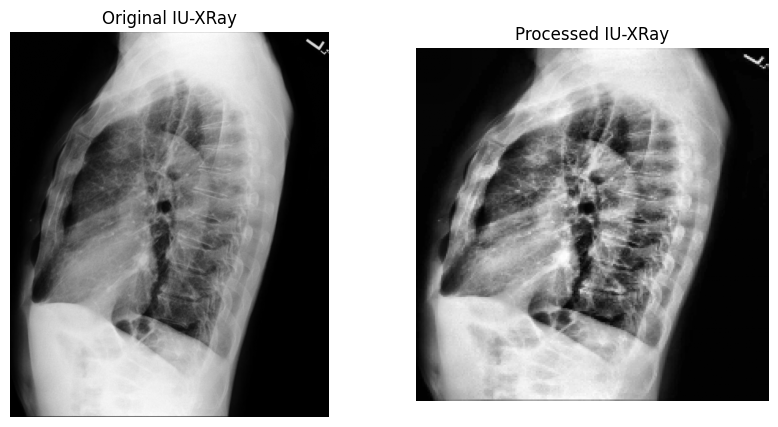

In [54]:
sample_path = iuxray_metadata.loc[0, "image_path"]

original = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
processed = preprocess_image(sample_path)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original, cmap="gray")
plt.title("Original IU-XRay")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(processed, cmap="gray")
plt.title("Processed IU-XRay")
plt.axis("off")

plt.show()

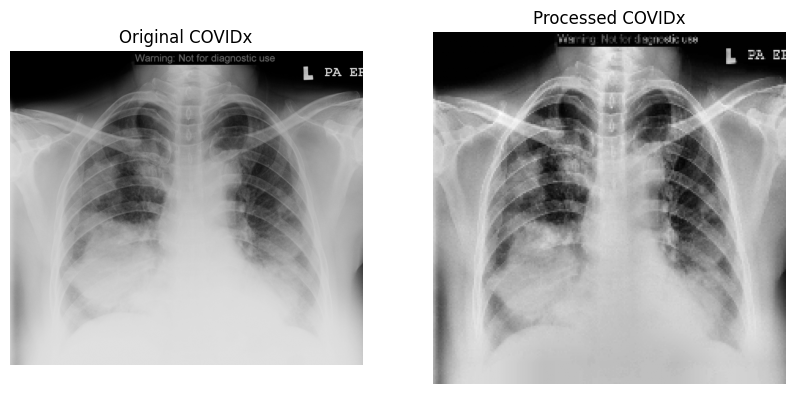

In [55]:
sample_path = covidx_metadata.loc[0, "image_path"]

original = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
processed = preprocess_image(sample_path)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original, cmap="gray")
plt.title("Original COVIDx")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(processed, cmap="gray")
plt.title("Processed COVIDx")
plt.axis("off")

plt.show()

In [57]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [59]:
class ChestXrayDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image = preprocess_image(row["image_path"])

        if self.transform:
            image = self.transform(image)

        sample = {
            "image": image,
            "metadata": row.to_dict()
        }

        return sample

In [63]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [61]:
nih_dataset = ChestXrayDataset(
    nih_metadata,
    transform=transform
)
print(len(nih_dataset))

112120


In [64]:
sample = nih_dataset[0]

print(sample.keys())

dict_keys(['image', 'metadata'])


In [65]:
print(sample["image"].shape)

torch.Size([1, 224, 224])


In [66]:
print(sample["metadata"])

{'image_name': '00000001_000.png', 'label': 'Cardiomegaly', 'image_path': '/kaggle/input/datasets/biditdas06/nih-chestxray14/images_001/images/00000001_000.png', 'dataset': 'NIH'}


# creating dataloader

In [68]:
nih_dataset = ChestXrayDataset(
    nih_metadata,
    transform=transform
)

iuxray_dataset = ChestXrayDataset(
    iuxray_metadata,
    transform=transform
)

covidx_dataset = ChestXrayDataset(
    covidx_metadata,
    transform=transform
)

In [70]:
nih_loader = DataLoader(
    nih_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

iuxray_loader = DataLoader(
    iuxray_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

covidx_loader = DataLoader(
    covidx_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

In [71]:
batch = next(iter(nih_loader))

print(batch["image"].shape)

torch.Size([16, 1, 224, 224])
